# 09 Collusion Network Construction

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `09-collusion-network-construction.ipynb`

In [1]:
# ==========================================
# Notebook 09
# Collusion Network Construction
# ==========================================

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

In [4]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [5]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [6]:
G = nx.Graph()

In [7]:
G

In [ ]:
for _, row in claims_df.iterrows():

    claimant = row["claimant_name"]

    mechanic = row["mechanic_shop"]

    clinic = row["clinic_name"]

    lawyer = row["lawyer"]

    G.add_node(claimant, node_type="claimant")

    G.add_node(mechanic, node_type="mechanic")

    G.add_node(clinic, node_type="clinic")

    G.add_node(lawyer, node_type="lawyer")
    G.add_edge(claimant, mechanic, relationship="used_mechanic")

    G.add_edge(claimant, clinic, relationship="visited_clinic")

    G.add_edge(claimant, lawyer, relationship="represented_by")

In [11]:
print("Nodes:", G.number_of_nodes())

print("Edges:", G.number_of_edges())

Nodes: 29
Edges: 45


In [12]:
node_types = nx.get_node_attributes(G, "node_type")

pd.Series(node_types.values()).value_counts()

claimant    15
mechanic     5
lawyer       5
clinic       4
Name: count, dtype: int64

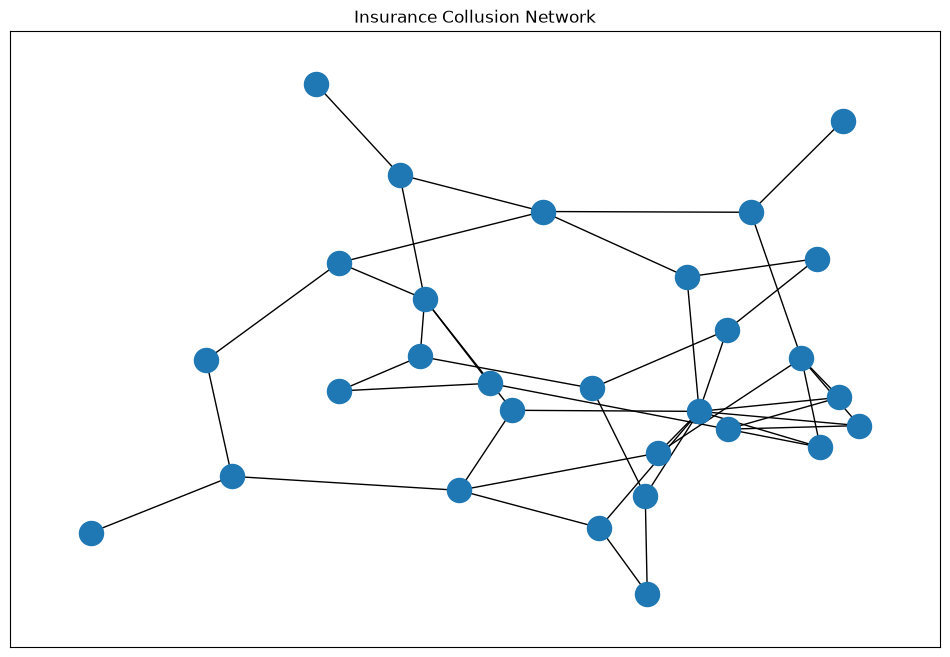

In [13]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(G, pos, with_labels=False, node_size=300)

plt.title("Insurance Collusion Network")

plt.show()

In [14]:
color_map = []

In [15]:
for node in G.nodes():

    node_type = G.nodes[node]["node_type"]

    if node_type == "claimant":
        color_map.append("lightblue")

    elif node_type == "mechanic":
        color_map.append("red")

    elif node_type == "clinic":
        color_map.append("green")

    else:
        color_map.append("orange")

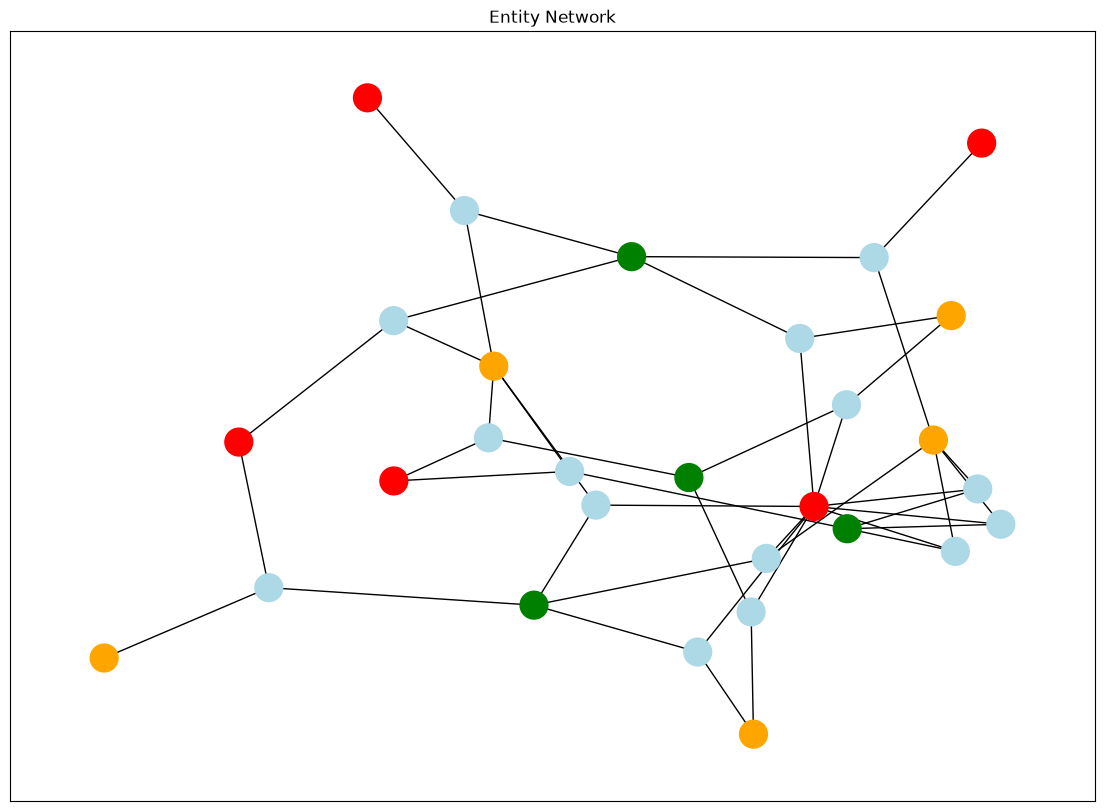

In [16]:
plt.figure(figsize=(14, 10))

nx.draw_networkx(G, pos, node_color=color_map, with_labels=False, node_size=400)

plt.title("Entity Network")

plt.show()

In [17]:
degree_centrality = nx.degree_centrality(G)

In [18]:
centrality_df = pd.DataFrame(
    {
        "entity": list(degree_centrality.keys()),
        "degree_centrality": list(degree_centrality.values()),
    }
)

In [19]:
centrality_df.sort_values(by="degree_centrality", ascending=False).head(15)

,entity,degree_centrality
1,Rapid Auto Repair,0.321429
15,Premier Injury Law,0.178571
3,Smith & Associates,0.178571
2,Care First Clinic,0.142857
20,Advanced Spine Center,0.142857
13,Metro Injury Clinic,0.142857
0,Wendy Holland,0.107143
27,Patricia Lopez,0.107143
25,Misty Smith,0.107143
23,Janice Zavala,0.107143


In [20]:
high_degree_entities = centrality_df.sort_values(
    by="degree_centrality", ascending=False
)

In [21]:
high_degree_entities.head(10)

,entity,degree_centrality
1,Rapid Auto Repair,0.321429
15,Premier Injury Law,0.178571
3,Smith & Associates,0.178571
2,Care First Clinic,0.142857
20,Advanced Spine Center,0.142857
13,Metro Injury Clinic,0.142857
0,Wendy Holland,0.107143
27,Patricia Lopez,0.107143
25,Misty Smith,0.107143
23,Janice Zavala,0.107143


In [22]:
components = list(nx.connected_components(G))

In [23]:
len(components)

1

In [24]:
component_sizes = [len(component) for component in components]

In [25]:
component_sizes

[29]

In [26]:
largest_component = max(components, key=len)

In [27]:
len(largest_component)

29

In [28]:
largest_component

{'Accident Recovery Group',
 'Advanced Spine Center',
 'Anderson Legal',
 'Care First Clinic',
 'Chloe Murphy',
 'Douglas Lara',
 'Elite Collision Center',
 'Elizabeth Patel',
 'Janice Zavala',
 'Jodi Reynolds MD',
 'Julia Wilson',
 'Justice Partners',
 'Kendra Reyes',
 'Kevin Paul',
 'Lisa Rich',
 'Metro Auto Works',
 'Metro Injury Clinic',
 'Misty Smith',
 'Pamela Hayes',
 'Patricia Lopez',
 'Patrick Harvey',
 'Premier Injury Law',
 'Prime Vehicle Repair',
 'Rapid Auto Repair',
 'Smith & Associates',
 'Stephanie Wood',
 'Trusted Auto Garage',
 'Wellness Recovery Center',
 'Wendy Holland'}

In [29]:
claims_df["mechanic_shop"].value_counts()

mechanic_shop
Rapid Auto Repair         9
Prime Vehicle Repair      2
Metro Auto Works          2
Elite Collision Center    1
Trusted Auto Garage       1
Name: count, dtype: int64

In [30]:
claims_df["clinic_name"].value_counts()

clinic_name
Care First Clinic           4
Metro Injury Clinic         4
Advanced Spine Center       4
Wellness Recovery Center    3
Name: count, dtype: int64

In [31]:
claims_df["lawyer"].value_counts()

lawyer
Smith & Associates         5
Premier Injury Law         5
Anderson Legal             2
Justice Partners           2
Accident Recovery Group    1
Name: count, dtype: int64

In [32]:
entity_scores = []

In [33]:
for mechanic in claims_df["mechanic_shop"].unique():

    count = len(claims_df[claims_df["mechanic_shop"] == mechanic])

    entity_scores.append({"entity": mechanic, "type": "mechanic", "claim_count": count})

In [34]:
entity_scores_df = pd.DataFrame(entity_scores)

In [35]:
entity_scores_df.sort_values(by="claim_count", ascending=False)

,entity,type,claim_count
0,Rapid Auto Repair,mechanic,9
1,Prime Vehicle Repair,mechanic,2
2,Metro Auto Works,mechanic,2
3,Elite Collision Center,mechanic,1
4,Trusted Auto Garage,mechanic,1


In [36]:
fraud_ring_candidates = entity_scores_df[entity_scores_df["claim_count"] >= 3]

In [37]:
fraud_ring_candidates

,entity,type,claim_count
0,Rapid Auto Repair,mechanic,9


In [38]:
investigation_queue = []

In [39]:
for _, row in fraud_ring_candidates.iterrows():

    investigation_queue.append(
        {
            "entity": row["entity"],
            "claim_count": row["claim_count"],
            "reason": "Repeated Entity Usage",
        }
    )

In [40]:
investigation_queue = pd.DataFrame(investigation_queue)

investigation_queue

,entity,claim_count,reason
0,Rapid Auto Repair,9,Repeated Entity Usage


In [41]:
centrality_df.to_csv("../data/network_centrality.csv", index=False)

In [42]:
investigation_queue.to_csv("../data/collusion_investigation_queue.csv", index=False)